# Final Model without NEF

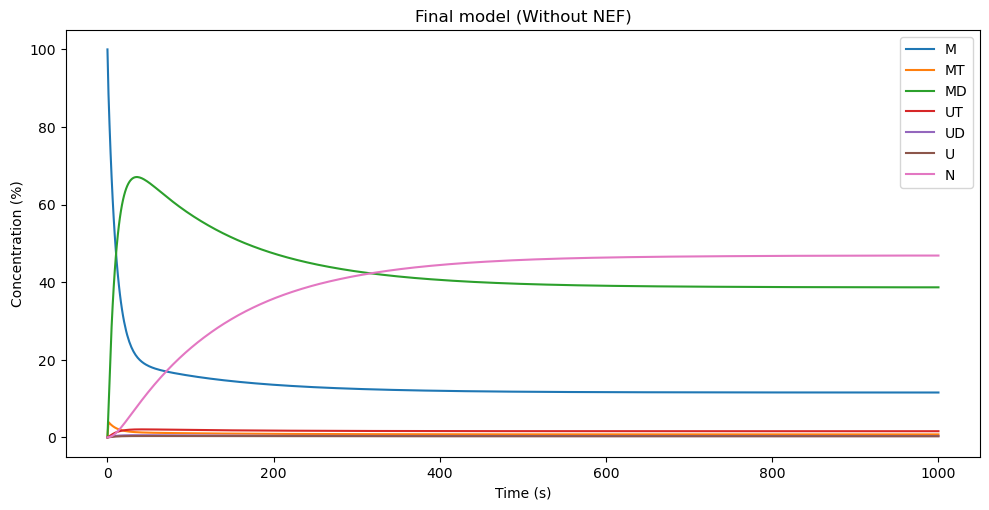

Max N: 46.85697450912233


In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def odes(t, y):
    M, MT, MD, UT, UD, U, N = y

    dM = -(k['kM_MT'] + k['kM_MD'] + k['kM_U']) * M \
         + k['kMT_M'] * MT + k['kMD_M'] * MD + k['kU_M'] * U

    dMT = -(k['kMT_M'] + k['kMT_MD'] + k['kMT_UT']) * MT \
          + k['kM_MT'] * M + k['kMD_MT'] * MD + k['kUT_MT'] * UT

    dMD = -(k['kMD_M'] + k['kMD_MT'] + k['kMD_UD']) * MD \
          + k['kM_MD'] * M + k['kMT_MD'] * MT + k['kUD_MD'] * UD

    dUT = -(k['kUT_U'] + k['kUT_UD'] + k['kUT_MT']) * UT \
          + k['kU_UT'] * U + k['kUD_UT'] * UD + k['kMT_UT'] * MT

    dUD = -(k['kUD_U'] + k['kUD_UT'] + k['kUD_MD']) * UD \
          + k['kU_UD'] * U + k['kUT_UD'] * UT + k['kMD_UD'] * MD

    dU = -(k['kU_UT'] + k['kU_UD'] + k['kU_M'] + k['kU_N']) * U \
         + k['kUT_U'] * UT + k['kUD_U'] * UD + k['kM_U'] * M + k['kN_U'] * N

    dN = -k['kN_U'] * N + k['kU_N'] * U

    return [dM, dMT, dMD, dUT, dUD, dU, dN]

DG_M_M70    = 2.5
DG_M70_U70  = 1.5
DG_U70_U    = 0
DG_M_U      = 4

tau= 60 

kATP_on_base = 1.28e+6   
kATP_off     = 2.31 
kADP_on_base = 1000 
kADP_off     = 2e-3 

kATP_plus = 1.3e+5
kATP_minus= 1.33e-4
kADP_plus = 2.67e+5
kADP_minus= 0.022

ksh = 1.8
k_h= 6e-4

Hsp70 = 10e-6 

ratio_ATP_ADP = 1e-9
ratio_ATP_ADP_neq = 10

r= kATP_on_base*kADP_off/(kADP_on_base*kATP_off )

kATP_on_base =  kATP_on_base*r**(-1/4)
kATP_off     =  kATP_off*r**(-1/4)
kADP_on_base =  kADP_on_base*r**(1/4)
kADP_off     =  kADP_off*r**(1/4)

keff_ex_TD = (kADP_plus*kATP_minus)/(kADP_plus + kATP_plus*(ratio_ATP_ADP_neq))
keff_ex_DT = (kADP_minus*kATP_plus*(ratio_ATP_ADP_neq))/(kADP_plus + kATP_plus*(ratio_ATP_ADP_neq)) 

k_s=k_h*(kATP_plus*kADP_minus/(kADP_plus*kATP_minus)*ratio_ATP_ADP)
kss= ksh*(k_s/k_h)

ratio_Hsp70_ATP_ADP = (keff_ex_DT+k_s)/(keff_ex_TD+k_h)     

alpha = 1
gamma = 5
beta= 1/0.592 

kATP_MU = kADP_MU = (1/tau) * np.exp(+beta*DG_M70_U70)

Hsp70_ADP = Hsp70/(1+ratio_Hsp70_ATP_ADP)
Hsp70_ATP = Hsp70 - Hsp70_ADP

#Rates
k = {}

k['kM_MT'] = kATP_on_base * Hsp70_ATP * np.exp(-beta*DG_M_M70)
k['kMT_M']  = kATP_off

k['kM_MD'] = kADP_on_base * Hsp70_ADP * np.exp(-beta*DG_M_M70)
k['kMD_M']  = kADP_off

k['kMT_MD'] = keff_ex_TD + ksh
k['kMD_MT'] = keff_ex_DT + kss 

k['kMT_UT'] = kATP_MU * np.exp(-beta*DG_M70_U70)
k['kUT_MT'] = k['kMT_UT'] * np.exp(+beta*DG_M70_U70)

k['kMD_UD'] = kADP_MU * np.exp(-beta*DG_M70_U70)
k['kUD_MD'] = k['kMD_UD'] * np.exp(+beta*DG_M70_U70)

k['kUT_U']  = kATP_off * np.exp(-beta*DG_U70_U)
k['kU_UT']  = kATP_on_base * Hsp70_ATP

k['kUD_U']  = kADP_off * np.exp(-beta*DG_U70_U)
k['kU_UD']  = kADP_on_base * Hsp70_ADP

#Assymetry
k['kUT_UD'] = keff_ex_TD*1e2 + ksh*1e-3
k['kUD_UT'] = keff_ex_DT*1e2 + kss*1e-3

k['kU_M']  = alpha
k['kM_U']  = k['kU_M'] * np.exp(-beta*DG_M_U)

k['kU_N']   = k['kU_M'] =alpha
k['kN_U']   = gamma * k['kM_U']


y0 = [100, 0, 0, 0, 0, 0, 0]
t_eval = np.linspace(0, 1000, 800)

sol = solve_ivp(odes, (0, 1000), y0, method="BDF", t_eval=t_eval)



plt.figure(figsize=(10,5))
labels = ["M", "MT", "MD", "UT", "UD", "U", "N"]

for i, lab in enumerate(labels):
    plt.plot(sol.t, sol.y[i], label=lab)

plt.xlabel("Time (s)")
plt.ylabel("Concentration (%)")
plt.legend()
plt.tight_layout()
plt.title("Final model (Without NEF)")
plt.show()

#N magnitude
print("Max N:", np.max(sol.y[6])) 

# T,D,TN,DN,NEF_free (non equilibrium)

=== Reduced model steady state ===
  T    = 5.027933e-06 M
  TN   = 4.899666e-06 M
  D    = 6.627874e-08 M
  DN   = 6.121960e-09 M
  NEF  = 9.421193e-08 M
  Hsp70 conservation : T+TN+D+DN = 1.000000e-05  (expected 1.000000e-05)
  NEF   conservation : TN+DN+NEF = 5.000000e-06  (expected 5.000000e-06)


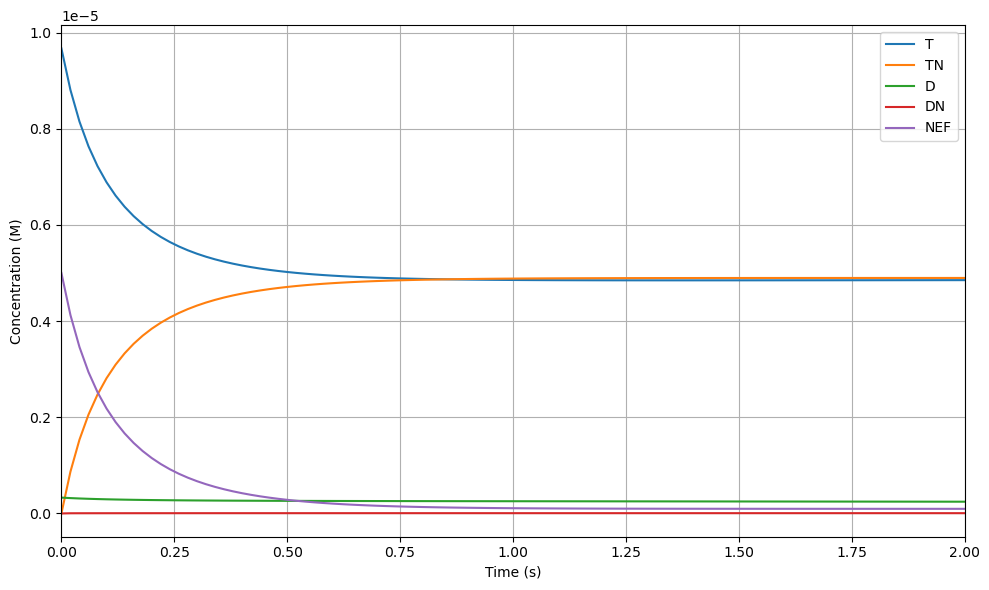

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def odes_reduced(t, y):
    T, TN, D, DN, NEF = y

    kT_TN = k_NEF_on_T * NEF
    kD_DN = k_NEF_on_D * NEF

    dT  = -(kT_TN + k_red['kT_D']) * T  + k_red['kTN_T']  * TN + k_red['kD_T']  * D
    
    dTN = -(k_red['kTN_T'] + k_red['kTN_DN']) * TN + kT_TN * T  + k_red['kDN_TN'] * DN
    
    dD  = -(k_red['kD_T']  + kD_DN)            * D  + k_red['kT_D']  * T  + k_red['kDN_D']  * DN
    
    dDN = -(k_red['kDN_TN'] + k_red['kDN_D'])  * DN + k_red['kTN_DN'] * TN + kD_DN * D
    
    dNEF = -(kT_TN * T + kD_DN * D) + (k_red['kTN_T'] * TN + k_red['kDN_D'] * DN)

    return [dT, dTN, dD, dDN, dNEF]


DG_M_M70    = 2.5
DG_M70_U70  = 1.5
DG_U70_U    = 0
DG_M_U      = 4
tau         = 60
beta        = 1 / 0.592

kATP_on_base = 1.28e6;  kATP_off = 2.31
kADP_on_base = 1000;    kADP_off = 2e-3
kATP_plus    = 1.3e5;   kATP_minus = 1.33e-4
kADP_plus    = 2.67e5;  kADP_minus = 0.022
ksh = 1.8;  k_h = 6e-4

Hsp70 = 10e-6
NEF0  = 5e-6

ratio_ATP_ADP     = 1e-9
ratio_ATP_ADP_neq = 10

# symmetrise on/off rates
r = kATP_on_base * kADP_off / (kADP_on_base * kATP_off)
kATP_on_base *= r**(-1/4);  kATP_off     *= r**(1/4)
kADP_on_base *= r**(1/4);   kADP_off     *= r**(-1/4)

# NEF binding parameters
k_NEF_off_D = 0.033;  k_NEF_on_D = 3.4e5
k_NEF_off_T = 0.1;    k_NEF_on_T = (k_NEF_on_D / k_NEF_off_D) * k_NEF_off_T

k_NEF_70T_on  = 6e6;  k_NEF_70T_off = 127;  k_NEF_70D_off = 127
k_NEF_70D_on  = (k_NEF_70T_on * k_NEF_70D_off / k_NEF_70T_off) \
                * (kATP_minus * kADP_plus) / (kATP_plus * kADP_minus)

# Exchange/hydrolysis — non-equilibrium (ratio_ATP_ADP_neq = 10)
keff_ex_TD = (kADP_plus * kATP_minus) / (kADP_plus + kATP_plus * ratio_ATP_ADP_neq)
keff_ex_DT = (kADP_minus * kATP_plus * ratio_ATP_ADP_neq) / (kADP_plus + kATP_plus * ratio_ATP_ADP_neq)
k_s=k_h*(kATP_plus*kADP_minus/(kADP_plus*kATP_minus)*ratio_ATP_ADP)
kss= ksh*(k_s/k_h)

kNEF_ex_TD = k_NEF_70T_off * (k_NEF_70D_on / (k_NEF_70T_on * ratio_ATP_ADP_neq + k_NEF_70D_on))
kNEF_ex_DT = k_NEF_70T_on  * (k_NEF_70D_off * ratio_ATP_ADP_neq / (k_NEF_70T_on * ratio_ATP_ADP_neq + k_NEF_70D_on))

ratio_Hsp70_ATP_ADP = (keff_ex_DT + k_s) / (keff_ex_TD + k_h)
Hsp70_ADP_0 = Hsp70 / (1 + ratio_Hsp70_ATP_ADP)
Hsp70_ATP_0 = Hsp70 - Hsp70_ADP_0

# reduced-model rate dict
k_red = {
    'kT_D':   keff_ex_TD + k_h,
    'kD_T':   keff_ex_DT + k_s,
    'kTN_DN': kNEF_ex_TD + k_h,
    'kDN_TN': kNEF_ex_DT + k_s,
    'kTN_T':  k_NEF_off_T,
    'kDN_D':  k_NEF_off_D,
}

sol_red = solve_ivp(
    odes_reduced, (0, 10000),
    [Hsp70_ATP_0, 0.0, Hsp70_ADP_0, 0.0, NEF0],
    method="BDF", t_eval=np.linspace(0, 10000, 500000),
    rtol=1e-9, atol=1e-12
)

T_ss, TN_ss, D_ss, DN_ss, NEF_ss = sol_red.y[:, -1]

print("=== Reduced model steady state ===")
for lab, v in zip(["T","TN","D","DN","NEF"], [T_ss, TN_ss, D_ss, DN_ss, NEF_ss]):
    print(f"  {lab:<4} = {v:.6e} M")
print(f"  Hsp70 conservation : T+TN+D+DN = {T_ss+TN_ss+D_ss+DN_ss:.6e}  (expected {Hsp70:.6e})")
print(f"  NEF   conservation : TN+DN+NEF = {TN_ss+DN_ss+NEF_ss:.6e}  (expected {NEF0:.6e})")

plt.figure(figsize=(10,6))

plt.plot(sol_red.t, sol_red.y[0], label='T')
plt.plot(sol_red.t, sol_red.y[1], label='TN')
plt.plot(sol_red.t, sol_red.y[2], label='D')
plt.plot(sol_red.t, sol_red.y[3], label='DN')
plt.plot(sol_red.t, sol_red.y[4], label='NEF')

plt.xlim(0, 2)

plt.xlabel('Time (s)')
plt.ylabel('Concentration (M)')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Final model with NEF

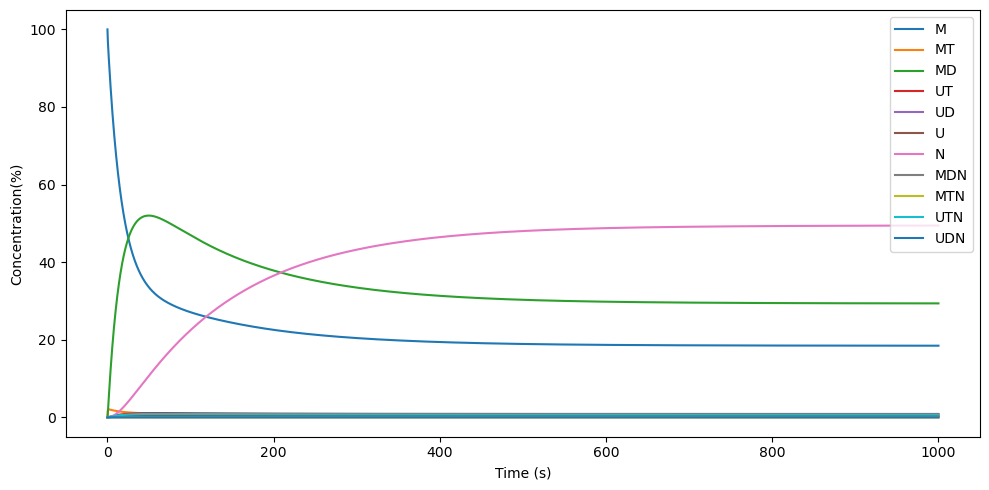

Max N: 49.43446964876924

Steady-state concentrations (%)
----------------------------------------
M     = 18.46559 %
MT    = 0.57702 %
MD    = 29.37184 %
UT    = 0.86652 %
UD    = 0.23831 %
U     = 0.28759 %
N     = 49.43651 %
MDN   = 0.00006 %
MTN   = 0.00711 %
UTN   = 0.74845 %
UDN   = 0.00100 %


In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ---------------- ODE SYSTEM ----------------

def odes(t, y):
    M, MT, MD, UT, UD, U, N, MDN, MTN, UTN, UDN = y

    dM = -(k['kM_MT'] + k['kM_MD'] + k['kM_U']
           + k['kM_MTN'] + k['kM_MDN']) * M \
         + k['kMT_M'] * MT + k['kMD_M'] * MD + k['kU_M'] * U \
         + k['kMTN_M'] * MTN + k['kMDN_M'] * MDN

    dMT = -(k['kMT_M'] + k['kMT_MD'] + k['kMT_UT'] + k['kMT_MTN']) * MT \
          + k['kM_MT'] * M + k['kMD_MT'] * MD + k['kUT_MT'] * UT + k['kMTN_MT'] * MTN

    dMD = -(k['kMD_M'] + k['kMD_MT'] + k['kMD_UD'] + k['kMD_MDN']) * MD \
          + k['kM_MD'] * M + k['kMT_MD'] * MT + k['kUD_MD'] * UD + k['kMDN_MD'] * MDN

    dUT = -(k['kUT_U'] + k['kUT_UD'] + k['kUT_MT'] + k['kUT_UTN']) * UT \
          + k['kU_UT'] * U + k['kUD_UT'] * UD + k['kMT_UT'] * MT + k['kUTN_UT'] * UTN

    dUD = -(k['kUD_U'] + k['kUD_UT'] + k['kUD_MD'] + k['kUD_UDN']) * UD \
          + k['kU_UD'] * U + k['kUT_UD'] * UT + k['kMD_UD'] * MD + k['kUDN_UD'] * UDN

    dU = -(k['kU_UT'] + k['kU_UD'] + k['kU_M'] + k['kU_N']
           + k['kU_UTN'] + k['kU_UDN']) * U \
         + k['kUT_U'] * UT + k['kUD_U'] * UD + k['kM_U'] * M + k['kN_U'] * N \
         + k['kUTN_U'] * UTN + k['kUDN_U'] * UDN

    dN = -k['kN_U'] * N + k['kU_N'] * U

    #NEF states
    dMDN = -(k['kMDN_MTN'] + k['kMDN_UDN'] + k['kMDN_MD'] + k['kMDN_M']) * MDN \
           + k['kMTN_MDN'] * MTN + k['kUDN_MDN'] * UDN + k['kMD_MDN'] * MD \
           + k['kM_MDN'] * M

    dMTN = -(k['kMTN_MDN'] + k['kMTN_MT'] + k['kMTN_UTN'] + k['kMTN_M']) * MTN \
           + k['kMDN_MTN'] * MDN + k['kMT_MTN'] * MT + k['kUTN_MTN'] * UTN \
           + k['kM_MTN'] * M

    dUTN = -(k['kUTN_MTN'] + k['kUTN_UT'] + k['kUTN_UDN'] + k['kUTN_U']) * UTN \
           + k['kMTN_UTN'] * MTN + k['kUT_UTN'] * UT + k['kUDN_UTN'] * UDN \
           + k['kU_UTN'] * U

    dUDN = -(k['kUDN_UTN'] + k['kUDN_MDN'] + k['kUDN_UD'] + k['kUDN_U']) * UDN \
           + k['kUTN_UDN'] * UTN + k['kMDN_UDN'] * MDN + k['kUD_UDN'] * UD \
           + k['kU_UDN'] * U

    return [dM, dMT, dMD, dUT, dUD, dU, dN, dMDN, dMTN, dUTN, dUDN]


# ---------------- PARAMETERS ----------------

DG_M_M70    = 2.5
DG_M70_U70  = 1.5
DG_U70_U    = 0
DG_M_U      = 4
tau         = 60
beta        = 1 / 0.592

kATP_on_base = 1.28e6;  kATP_off = 2.31
kADP_on_base = 1000;    kADP_off = 2e-3
kATP_plus    = 1.3e5;   kATP_minus = 1.33e-4
kADP_plus    = 2.67e5;  kADP_minus = 0.022
ksh = 1.8;  k_h = 6e-4

Hsp70 = 10e-6
NEF0  = 5e-6

ratio_ATP_ADP     = 1e-9
ratio_ATP_ADP_neq = 10

# symmetrise on/off rates
r = kATP_on_base * kADP_off / (kADP_on_base * kATP_off)
kATP_on_base *= r**(-1/4);  kATP_off     *= r**(1/4)
kADP_on_base *= r**(1/4);   kADP_off     *= r**(-1/4)

# NEF binding parameters
k_NEF_off_D = 0.033;  k_NEF_on_D = 3.4e5
k_NEF_off_T = 0.1;    k_NEF_on_T = (k_NEF_on_D / k_NEF_off_D) * k_NEF_off_T

k_NEF_70T_on  = 6e6;  k_NEF_70T_off = 127;  k_NEF_70D_off = 127
k_NEF_70D_on  = (k_NEF_70T_on * k_NEF_70D_off / k_NEF_70T_off) \
                * (kATP_minus * kADP_plus) / (kATP_plus * kADP_minus)

keff_ex_TD = (kADP_plus * kATP_minus) / (kADP_plus + kATP_plus * ratio_ATP_ADP_neq)
keff_ex_DT = (kADP_minus * kATP_plus * ratio_ATP_ADP_neq) / (kADP_plus + kATP_plus * ratio_ATP_ADP_neq)
kss         = ksh * (k_s / k_h)

kNEF_ex_TD = k_NEF_70T_off * (k_NEF_70D_on / (k_NEF_70T_on * ratio_ATP_ADP_neq + k_NEF_70D_on))
kNEF_ex_DT = k_NEF_70T_on  * (k_NEF_70D_off * ratio_ATP_ADP_neq / (k_NEF_70T_on * ratio_ATP_ADP_neq + k_NEF_70D_on))

ratio_Hsp70_ATP_ADP = (keff_ex_DT + k_s) / (keff_ex_TD + k_h)
Hsp70_ADP_0 = Hsp70 / (1 + ratio_Hsp70_ATP_ADP)
Hsp70_ATP_0 = Hsp70 - Hsp70_ADP_0

# Exchange/hydrolysis — non-equilibrium (ratio_ATP_ADP_neq = 10)
keff_ex_TD = (kADP_plus * kATP_minus) / (kADP_plus + kATP_plus * ratio_ATP_ADP_neq)
keff_ex_DT = (kADP_minus * kATP_plus * ratio_ATP_ADP_neq) / (kADP_plus + kATP_plus * ratio_ATP_ADP_neq)
k_s=k_h*(kATP_plus*kADP_minus/(kADP_plus*kATP_minus)*ratio_ATP_ADP)
kss         = ksh * (k_s / k_h)

# Fixed Hsp70/NEF concentrations from reduced SS
Hsp70_ADP     = 6.627874e-08
Hsp70_ATP     = 5.027933e-06

Hsp70_ATP_NEF = 4.899666e-06
Hsp70_ADP_NEF = 6.121960e-09
NEF_free      = 9.421193e-08

DG_M70_M70N  = 3
DG_M70N_U70N = -1.5
DG_U70_U70N  = 0
DG_UTN_U     = 0
DG_UDN_U     = 0
DG_M_MTN     = DG_M_M70 + DG_M70_M70N
DG_M_MDN     = DG_M_M70 + DG_M70_M70N

k_TN_on = kATP_on_base
k_TN_off = kATP_off
k_DN_on = kADP_on_base
k_DN_off = kADP_off


alpha = 1;  gamma = 5;  tau_prime = tau
kATP_MU = kADP_MU = (1/tau) * np.exp(beta * DG_M70_U70)


# ---------------- RATES ----------------
k = {}
k['kM_MT'] = kATP_on_base * Hsp70_ATP * np.exp(-beta*DG_M_M70)
k['kMT_M']  = kATP_off

k['kM_MD'] = kADP_on_base * Hsp70_ADP * np.exp(-beta*DG_M_M70)
k['kMD_M']  = kADP_off

k['kMT_MD'] = keff_ex_TD + ksh
k['kMD_MT'] = keff_ex_DT + kss 

k['kMT_UT'] = kATP_MU * np.exp(-beta*DG_M70_U70)
k['kUT_MT'] = k['kMT_UT'] * np.exp(+beta*DG_M70_U70)

k['kMD_UD'] = kADP_MU * np.exp(-beta*DG_M70_U70)
k['kUD_MD'] = k['kMD_UD'] * np.exp(+beta*DG_M70_U70)

k['kUT_U']  = kATP_off * np.exp(-beta*DG_U70_U)
k['kU_UT']  = kATP_on_base * Hsp70_ATP

k['kUD_U']  = kADP_off * np.exp(-beta*DG_U70_U)
k['kU_UD']  = kADP_on_base * Hsp70_ADP

#Assymetry
k['kUT_UD'] = keff_ex_TD*1e2 + ksh*1e-3
k['kUD_UT'] = keff_ex_DT*1e2 + kss*1e-3

k['kU_M']  = alpha
k['kM_U']  = k['kU_M'] * np.exp(-beta*DG_M_U)

k['kU_N']   = k['kU_M'] =alpha
k['kN_U']   = gamma * k['kM_U']


k['kMTN_MDN'] = kNEF_ex_TD + ksh * 1e-3
k['kMDN_MTN'] = kNEF_ex_DT + kss * 1e-3
k['kMDN_UDN'] = 1 / tau_prime
k['kUDN_MDN'] = k['kMDN_UDN'] * np.exp(+beta * DG_M70N_U70N)
k['kMDN_MD']  = k_NEF_off_D
k['kMD_MDN']  = k_NEF_on_D * NEF_free * np.exp(-beta * DG_M70_M70N)
k['kMTN_MT']  = k_NEF_off_T
k['kMT_MTN']  = k_NEF_on_T * NEF_free * np.exp(-beta * DG_M70_M70N)
k['kMTN_UTN'] = 1 / tau_prime
k['kUTN_MTN'] = k['kMTN_UTN'] * np.exp(+beta * DG_M70N_U70N)
k['kUT_UTN']  = k_NEF_on_T * NEF_free * np.exp(-beta * DG_U70_U70N)
k['kUTN_UT']  = k_NEF_off_T
k['kUTN_UDN'] = kNEF_ex_TD + ksh * 1e-3
k['kUDN_UTN'] = kNEF_ex_DT + kss * 1e-3
k['kUD_UDN']  = k_NEF_on_D * NEF_free * np.exp(-beta * DG_U70_U70N)
k['kUDN_UD']  = k_NEF_off_D
k['kUTN_U']   = k_TN_off * np.exp(-beta * DG_UTN_U)
k['kU_UTN']   = k_TN_on  * Hsp70_ATP_NEF
k['kUDN_U']   = k_DN_off * np.exp(-beta * DG_UDN_U)
k['kU_UDN']   = k_DN_on  * Hsp70_ADP_NEF
k['kMTN_M']   = k_TN_off
k['kM_MTN']   = k_TN_on  * Hsp70_ATP_NEF * np.exp(-beta * DG_M_MTN)
k['kMDN_M']   = k_DN_off
k['kM_MDN']   = k_DN_on  * Hsp70_ADP_NEF * np.exp(-beta * DG_M_MDN)

# ---------------- SOLVE ----------------

y0 = [100,0,0,0,0,0,0,0,0,0,0]
t_eval = np.linspace(0,1000,10000)

sol = solve_ivp(odes,(0,10000),y0,method="BDF",t_eval=t_eval)


# ---------------- PLOT ----------------

plt.figure(figsize=(10,5))
labels = ["M","MT","MD","UT","UD","U","N","MDN","MTN","UTN","UDN"]

for i,lab in enumerate(labels):
    plt.plot(sol.t, sol.y[i], label=lab)

plt.xlabel("Time (s)")
plt.ylabel("Concentration(%)")
plt.legend()
plt.tight_layout()
plt.show()

#N magnitude
print("Max N:", np.max(sol.y[6])) 

# ---------------- STEADY STATE (%) ----------------

ss = sol.y[:, -1]          
total = np.sum(ss)         

print("\nSteady-state concentrations (%)")
print("-" * 40)

for i, lab in enumerate(labels):
    percent = 100 * ss[i] / total
    print(f"{lab:5s} = {percent:.5f} %")

# T,D,TN,DN,NEF_free (equilibrium) for detailed balance check

In [4]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def odes_reduced(t, y):
    T, TN, D, DN, NEF = y

    kT_TN = k_NEF_on_T * NEF
    kD_DN = k_NEF_on_D * NEF

    dT  = -(kT_TN + k_red['kT_D']) * T  + k_red['kTN_T']  * TN + k_red['kD_T']  * D
    
    dTN = -(k_red['kTN_T'] + k_red['kTN_DN']) * TN + kT_TN * T  + k_red['kDN_TN'] * DN
    
    dD  = -(k_red['kD_T']  + kD_DN)            * D  + k_red['kT_D']  * T  + k_red['kDN_D']  * DN
    
    dDN = -(k_red['kDN_TN'] + k_red['kDN_D'])  * DN + k_red['kTN_DN'] * TN + kD_DN * D
    
    dNEF = -(kT_TN * T + kD_DN * D) + (k_red['kTN_T'] * TN + k_red['kDN_D'] * DN)

    return [dT, dTN, dD, dDN, dNEF]


DG_M_M70    = 2.5
DG_M70_U70  = 1.5
DG_U70_U    = 0
DG_M_U      = 4
tau         = 60
beta        = 1 / 0.592

kATP_on_base = 1.28e6;  kATP_off = 2.31
kADP_on_base = 1000;    kADP_off = 2e-3
kATP_plus    = 1.3e5;   kATP_minus = 1.33e-4
kADP_plus    = 2.67e5;  kADP_minus = 0.022
ksh = 1.8;  k_h = 6e-4

Hsp70 = 10e-6
NEF0  = 5e-6

ratio_ATP_ADP     = 1e-9
ratio_ATP_ADP_neq = 10

# symmetrise on/off rates
r = kATP_on_base * kADP_off / (kADP_on_base * kATP_off)
kATP_on_base *= r**(-1/4);  kATP_off     *= r**(1/4)
kADP_on_base *= r**(1/4);   kADP_off     *= r**(-1/4)

# NEF binding parameters
k_NEF_off_D = 0.033;  k_NEF_on_D = 3.4e5
k_NEF_off_T = 0.1;    k_NEF_on_T = (k_NEF_on_D / k_NEF_off_D) * k_NEF_off_T

k_NEF_70T_on  = 6e6;  k_NEF_70T_off = 127;  k_NEF_70D_off = 127
k_NEF_70D_on  = (k_NEF_70T_on * k_NEF_70D_off / k_NEF_70T_off) \
                * (kATP_minus * kADP_plus) / (kATP_plus * kADP_minus)

# Exchange/hydrolysis — non-equilibrium (ratio_ATP_ADP_neq = 10)
keff_ex_TD = (kADP_plus * kATP_minus) / (kADP_plus + kATP_plus * ratio_ATP_ADP)
keff_ex_DT = (kADP_minus * kATP_plus * ratio_ATP_ADP) / (kADP_plus + kATP_plus * ratio_ATP_ADP)
kss         = ksh * (k_s / k_h)

kNEF_ex_TD = k_NEF_70T_off * (k_NEF_70D_on / (k_NEF_70T_on * ratio_ATP_ADP + k_NEF_70D_on))
kNEF_ex_DT = k_NEF_70T_on  * (k_NEF_70D_off * ratio_ATP_ADP / (k_NEF_70T_on * ratio_ATP_ADP + k_NEF_70D_on))

ratio_Hsp70_ATP_ADP = (keff_ex_DT + k_s) / (keff_ex_TD + k_h)
Hsp70_ADP_0 = Hsp70 / (1 + ratio_Hsp70_ATP_ADP)
Hsp70_ATP_0 = Hsp70 - Hsp70_ADP_0

# reduced-model rate dict
k_red = {
    'kT_D':   keff_ex_TD + k_h,
    'kD_T':   keff_ex_DT + k_s,
    'kTN_DN': kNEF_ex_TD + k_h,
    'kDN_TN': kNEF_ex_DT + k_s,
    'kTN_T':  k_NEF_off_T,
    'kDN_D':  k_NEF_off_D,
}

sol_red = solve_ivp(
    odes_reduced, (0, 10000),
    [Hsp70_ATP_0, 0.0, Hsp70_ADP_0, 0.0, NEF0],
    method="BDF", t_eval=np.linspace(0, 10000, 5000),
    rtol=1e-9, atol=1e-12
)

T_ss, TN_ss, D_ss, DN_ss, NEF_ss = sol_red.y[:, -1]

print("=== Reduced model steady state ===")
for lab, v in zip(["T","TN","D","DN","NEF"], [T_ss, TN_ss, D_ss, DN_ss, NEF_ss]):
    print(f"  {lab:<4} = {v:.6e} M")
print(f"  Hsp70 conservation : T+TN+D+DN = {T_ss+TN_ss+D_ss+DN_ss:.6e}  (expected {Hsp70:.6e})")
print(f"  NEF   conservation : TN+DN+NEF = {TN_ss+DN_ss+NEF_ss:.6e}  (expected {NEF0:.6e})")

=== Reduced model steady state ===
  T    = 4.102221e-13 M
  TN   = 3.951621e-13 M
  D    = 5.093495e-06 M
  DN   = 4.906504e-06 M
  NEF  = 9.349562e-08 M
  Hsp70 conservation : T+TN+D+DN = 1.000000e-05  (expected 1.000000e-05)
  NEF   conservation : TN+DN+NEF = 5.000000e-06  (expected 5.000000e-06)


# Detailed balance check (equilibrium)

In [5]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ---------------- ODE SYSTEM ----------------

def odes(t, y):
    M, MT, MD, UT, UD, U, N, MDN, MTN, UTN, UDN = y

    dM = -(k['kM_MT'] + k['kM_MD'] + k['kM_U']
           + k['kM_MTN'] + k['kM_MDN']) * M \
         + k['kMT_M'] * MT + k['kMD_M'] * MD + k['kU_M'] * U \
         + k['kMTN_M'] * MTN + k['kMDN_M'] * MDN

    dMT = -(k['kMT_M'] + k['kMT_MD'] + k['kMT_UT'] + k['kMT_MTN']) * MT \
          + k['kM_MT'] * M + k['kMD_MT'] * MD + k['kUT_MT'] * UT + k['kMTN_MT'] * MTN

    dMD = -(k['kMD_M'] + k['kMD_MT'] + k['kMD_UD'] + k['kMD_MDN']) * MD \
          + k['kM_MD'] * M + k['kMT_MD'] * MT + k['kUD_MD'] * UD + k['kMDN_MD'] * MDN

    dUT = -(k['kUT_U'] + k['kUT_UD'] + k['kUT_MT'] + k['kUT_UTN']) * UT \
          + k['kU_UT'] * U + k['kUD_UT'] * UD + k['kMT_UT'] * MT + k['kUTN_UT'] * UTN

    dUD = -(k['kUD_U'] + k['kUD_UT'] + k['kUD_MD'] + k['kUD_UDN']) * UD \
          + k['kU_UD'] * U + k['kUT_UD'] * UT + k['kMD_UD'] * MD + k['kUDN_UD'] * UDN

    dU = -(k['kU_UT'] + k['kU_UD'] + k['kU_M'] + k['kU_N']
           + k['kU_UTN'] + k['kU_UDN']) * U \
         + k['kUT_U'] * UT + k['kUD_U'] * UD + k['kM_U'] * M + k['kN_U'] * N \
         + k['kUTN_U'] * UTN + k['kUDN_U'] * UDN

    dN = -k['kN_U'] * N + k['kU_N'] * U

    # NEF states
    dMDN = -(k['kMDN_MTN'] + k['kMDN_UDN'] + k['kMDN_MD'] + k['kMDN_M']) * MDN \
           + k['kMTN_MDN'] * MTN + k['kUDN_MDN'] * UDN + k['kMD_MDN'] * MD \
           + k['kM_MDN'] * M

    dMTN = -(k['kMTN_MDN'] + k['kMTN_MT'] + k['kMTN_UTN'] + k['kMTN_M']) * MTN \
           + k['kMDN_MTN'] * MDN + k['kMT_MTN'] * MT + k['kUTN_MTN'] * UTN \
           + k['kM_MTN'] * M

    dUTN = -(k['kUTN_MTN'] + k['kUTN_UT'] + k['kUTN_UDN'] + k['kUTN_U']) * UTN \
           + k['kMTN_UTN'] * MTN + k['kUT_UTN'] * UT + k['kUDN_UTN'] * UDN \
           + k['kU_UTN'] * U

    dUDN = -(k['kUDN_UTN'] + k['kUDN_MDN'] + k['kUDN_UD'] + k['kUDN_U']) * UDN \
           + k['kUTN_UDN'] * UTN + k['kMDN_UDN'] * MDN + k['kUD_UDN'] * UD \
           + k['kU_UDN'] * U

    return [dM, dMT, dMD, dUT, dUD, dU, dN, dMDN, dMTN, dUTN, dUDN]


# ---------------- PARAMETERS ----------------

DG_M_M70    = 2.5
DG_M70_U70  = 1.5
DG_U70_U    = 0
DG_M_U      = 4
tau         = 60
beta        = 1 / 0.592

kATP_on_base = 1.28e6;  kATP_off = 2.31
kADP_on_base = 1000;    kADP_off = 2e-3
kATP_plus    = 1.3e5;   kATP_minus = 1.33e-4
kADP_plus    = 2.67e5;  kADP_minus = 0.022
ksh = 1.8;  k_h = 6e-4

Hsp70 = 10e-6
NEF0  = 5e-6

ratio_ATP_ADP     = 1e-9
ratio_ATP_ADP_neq = 10

# symmetrise on/off rates
r = kATP_on_base * kADP_off / (kADP_on_base * kATP_off)
kATP_on_base *= r**(-1/4);  kATP_off     *= r**(1/4)
kADP_on_base *= r**(1/4);   kADP_off     *= r**(-1/4)

# NEF binding parameters
k_NEF_off_D = 0.033;  k_NEF_on_D = 3.4e5
k_NEF_off_T = 0.1;    k_NEF_on_T = (k_NEF_on_D / k_NEF_off_D) * k_NEF_off_T

k_NEF_70T_on  = 6e6;  k_NEF_70T_off = 127;  k_NEF_70D_off = 127
k_NEF_70D_on  = (k_NEF_70T_on * k_NEF_70D_off / k_NEF_70T_off) \
                * (kATP_minus * kADP_plus) / (kATP_plus * kADP_minus)

# Exchange/hydrolysis — non-equilibrium (ratio_ATP_ADP_neq = 10)
keff_ex_TD = (kADP_plus * kATP_minus) / (kADP_plus + kATP_plus * ratio_ATP_ADP)
keff_ex_DT = (kADP_minus * kATP_plus * ratio_ATP_ADP) / (kADP_plus + kATP_plus * ratio_ATP_ADP)
kss         = ksh * (k_s / k_h)

kNEF_ex_TD = k_NEF_70T_off * (k_NEF_70D_on / (k_NEF_70T_on * ratio_ATP_ADP + k_NEF_70D_on))
kNEF_ex_DT = k_NEF_70T_on  * (k_NEF_70D_off * ratio_ATP_ADP / (k_NEF_70T_on * ratio_ATP_ADP + k_NEF_70D_on))

ratio_Hsp70_ATP_ADP = (keff_ex_DT + k_s) / (keff_ex_TD + k_h)
Hsp70_ADP_0 = Hsp70 / (1 + ratio_Hsp70_ATP_ADP)
Hsp70_ATP_0 = Hsp70 - Hsp70_ADP_0

# Exchange/hydrolysis — non-equilibrium (ratio_ATP_ADP_neq = 10)
keff_ex_TD = (kADP_plus * kATP_minus) / (kADP_plus + kATP_plus * ratio_ATP_ADP)
keff_ex_DT = (kADP_minus * kATP_plus * ratio_ATP_ADP) / (kADP_plus + kATP_plus * ratio_ATP_ADP)
kss         = ksh * (k_s / k_h)

# Fixed Hsp70/NEF concentrations from reduced SS
Hsp70_ADP     = 5.093495e-06
Hsp70_ATP     = 4.076766e-13

Hsp70_ATP_NEF = 3.951583e-13
Hsp70_ADP_NEF = 4.906504e-06
NEF_free      = 9.349562e-08

DG_M70_M70N  = 3
DG_M70N_U70N = -1.5
DG_U70_U70N  = 0
DG_UTN_U     = 0
DG_UDN_U     = 0
DG_M_MTN     = DG_M_M70 + DG_M70_M70N
DG_M_MDN     = DG_M_M70 + DG_M70_M70N

k_TN_on = kATP_on_base
k_TN_off = kATP_off
k_DN_on = kADP_on_base
k_DN_off = kADP_off


alpha = 1;  gamma = 5;  tau_prime = tau
kATP_MU = kADP_MU = (1/tau) * np.exp(beta * DG_M70_U70)


# ---------------- RATES ----------------
k = {}
k['kM_MT'] = kATP_on_base * Hsp70_ATP * np.exp(-beta*DG_M_M70)
k['kMT_M']  = kATP_off

k['kM_MD'] = kADP_on_base * Hsp70_ADP * np.exp(-beta*DG_M_M70)
k['kMD_M']  = kADP_off

k['kMT_MD'] = keff_ex_TD + ksh
k['kMD_MT'] = keff_ex_DT + kss 

k['kMT_UT'] = kATP_MU * np.exp(-beta*DG_M70_U70)
k['kUT_MT'] = k['kMT_UT'] * np.exp(+beta*DG_M70_U70)

k['kMD_UD'] = kADP_MU * np.exp(-beta*DG_M70_U70)
k['kUD_MD'] = k['kMD_UD'] * np.exp(+beta*DG_M70_U70)

k['kUT_U']  = kATP_off * np.exp(-beta*DG_U70_U)
k['kU_UT']  = kATP_on_base * Hsp70_ATP

k['kUD_U']  = kADP_off * np.exp(-beta*DG_U70_U)
k['kU_UD']  = kADP_on_base * Hsp70_ADP

#Assymetry
k['kUT_UD'] = keff_ex_TD*1e2 + ksh*1e-3
k['kUD_UT'] = keff_ex_DT*1e2 + kss*1e-3

k['kU_M']  = alpha
k['kM_U']  = k['kU_M'] * np.exp(-beta*DG_M_U)

k['kU_N']   = k['kU_M'] =alpha
k['kN_U']   = gamma * k['kM_U']


k['kMTN_MDN'] = kNEF_ex_TD + ksh * 1e-3
k['kMDN_MTN'] = kNEF_ex_DT + kss * 1e-3
k['kMDN_UDN'] = 1 / tau_prime
k['kUDN_MDN'] = k['kMDN_UDN'] * np.exp(+beta * DG_M70N_U70N)
k['kMDN_MD']  = k_NEF_off_D
k['kMD_MDN']  = k_NEF_on_D * NEF_free * np.exp(-beta * DG_M70_M70N)
k['kMTN_MT']  = k_NEF_off_T
k['kMT_MTN']  = k_NEF_on_T * NEF_free * np.exp(-beta * DG_M70_M70N)
k['kMTN_UTN'] = 1 / tau_prime
k['kUTN_MTN'] = k['kMTN_UTN'] * np.exp(+beta * DG_M70N_U70N)
k['kUT_UTN']  = k_NEF_on_T * NEF_free * np.exp(-beta * DG_U70_U70N)
k['kUTN_UT']  = k_NEF_off_T
k['kUTN_UDN'] = kNEF_ex_TD + ksh * 1e-3
k['kUDN_UTN'] = kNEF_ex_DT + kss * 1e-3
k['kUD_UDN']  = k_NEF_on_D * NEF_free * np.exp(-beta * DG_U70_U70N)
k['kUDN_UD']  = k_NEF_off_D
k['kUTN_U']   = k_TN_off * np.exp(-beta * DG_UTN_U)
k['kU_UTN']   = k_TN_on  * Hsp70_ATP_NEF
k['kUDN_U']   = k_DN_off * np.exp(-beta * DG_UDN_U)
k['kU_UDN']   = k_DN_on  * Hsp70_ADP_NEF
k['kMTN_M']   = k_TN_off
k['kM_MTN']   = k_TN_on  * Hsp70_ATP_NEF * np.exp(-beta * DG_M_MTN)
k['kMDN_M']   = k_DN_off
k['kM_MDN']   = k_DN_on  * Hsp70_ADP_NEF * np.exp(-beta * DG_M_MDN)

# ---------------- DETAILED BALANCE ----------------

# MT-UT-UD-MD
print("MT-UT-UD-MD (exchange):",
      ((1/tau)*(keff_ex_TD*(1/tau)*keff_ex_DT)) /
      (keff_ex_TD*(1/tau)*keff_ex_DT*(1/tau)))

print("MT-UT-UD-MD (hydrolysis):",
      ((1/tau)*(ksh*(1/tau)*kss)) /
      (ksh*(1/tau)*kss*(1/tau)))


# M-MT-MD
print("M-MT-MD:",
      (kATP_on_base*Hsp70_ATP*keff_ex_TD*kADP_off /
      (kADP_on_base*Hsp70_ADP*keff_ex_DT*kATP_off)))


# U-UT-UD
print("U-UT-UD (exchange):",
      (kATP_on_base*Hsp70_ATP*keff_ex_TD*kADP_off /
      (kADP_on_base*Hsp70_ADP*keff_ex_DT*kATP_off)))

print("U-UT-UD (hydrolisis):",
      (kATP_on_base*Hsp70_ATP*ksh*kADP_off /
      (kADP_on_base*Hsp70_ADP*kss*kATP_off)))


# M-MT-MTN
print("M-MT-MTN:",
      ((kATP_on_base*Hsp70_ATP*k_NEF_on_T*NEF_free*k_TN_off)/
       (k_TN_on*Hsp70_ATP_NEF*k_NEF_off_T*kATP_off)
      ))

# M-MD-MDN
print("M-MD-MDN:",
      ((kADP_on_base*Hsp70_ADP*k_NEF_on_D*NEF_free*k_DN_off)/
       (k_DN_on*Hsp70_ADP_NEF*k_NEF_off_D*kADP_off)
      ))

# U-UD-UDN
print("U-UD-UDN:",
      ((kADP_on_base*Hsp70_ADP*k_NEF_on_D*NEF_free*k_DN_off)/
       (k_DN_on*Hsp70_ADP_NEF*k_NEF_off_D*kADP_off)
      ))

# M-MT-UT-U-UD-MD
print("M-MT-UT-U-UD-MD:",
      (kATP_on_base*(1/tau)*kATP_off*kADP_on_base*(1/tau)*kADP_off)/
      (kADP_on_base*(1/tau)*kADP_off*kATP_on_base*(1/tau)*kATP_off))


# MT-MTN-UTN-UT
print("MT-MTN-UTN-UT:",
      ((k_NEF_on_T*(1/tau)*k_NEF_off_T*(1/tau))/
       ((1/tau)*k_NEF_on_T*(1/tau)*k_NEF_off_T)))

# MD-MDN-UDN-UD
print("MD-MDN-UDN-UD:",
      ((k_NEF_on_D*(1/tau)*k_NEF_off_D*(1/tau))/
       ((1/tau)*k_NEF_on_D*(1/tau)*k_NEF_off_D)))


# MDN-MTN-M
print("MDN-MTN-M:",
      ((kNEF_ex_DT*k_TN_off*k_DN_on*Hsp70_ADP_NEF)/
       (k_DN_off*k_TN_on*Hsp70_ATP_NEF*kNEF_ex_TD)))



# UDN-UTN-U
print("UDN-UTN-U:",
      (kNEF_ex_DT*k_TN_off*k_DN_on*Hsp70_ADP_NEF)/
       (k_DN_off*k_TN_on*Hsp70_ATP_NEF*kNEF_ex_TD))


# MT-MD-MDN-MTN
print("MT-MD-MDN-MTN:",
      (k_NEF_on_T*kNEF_ex_TD*k_NEF_off_D*keff_ex_DT)/
      (keff_ex_TD*k_NEF_on_D*kNEF_ex_DT*k_NEF_off_T))


# UT-UTN-UDN-UD
print("UT-UD-UDN-UTN:",
     (k_NEF_on_T*kNEF_ex_TD*k_NEF_off_D*keff_ex_DT)/
      (keff_ex_TD*k_NEF_on_D*kNEF_ex_DT*k_NEF_off_T))

# UTN-UDN-MDN-MTN
print("UTN-UDN-MDN-MTN:",
     (kNEF_ex_TD*(1/tau)*kNEF_ex_DT*(1/tau))/
      ((1/tau)*kNEF_ex_TD*(1/tau)*kNEF_ex_DT))



MT-UT-UD-MD (exchange): 1.0
MT-UT-UD-MD (hydrolysis): 1.0
M-MT-MD: 0.9937949130193531
U-UT-UD (exchange): 0.9937949130193531
U-UT-UD (hydrolisis): 0.993794913019353
M-MT-MTN: 0.9938044086809952
M-MD-MDN: 0.9999999309342593
U-UD-UDN: 0.9999999309342593
M-MT-UT-U-UD-MD: 0.9999999999999999
MT-MTN-UTN-UT: 1.0000000000000002
MD-MDN-UDN-UD: 1.0000000000000002
MDN-MTN-M: 1.0000096240173488
UDN-UTN-U: 1.0000096240173488
MT-MD-MDN-MTN: 1.0
UT-UD-UDN-UTN: 1.0
UTN-UDN-MDN-MTN: 1.0


# Simplified computational script & net fluxes

Hsp70_ATP: 5.0279e-06, Hsp70_ADP: 6.6279e-08, NEF_free: 9.4212e-08



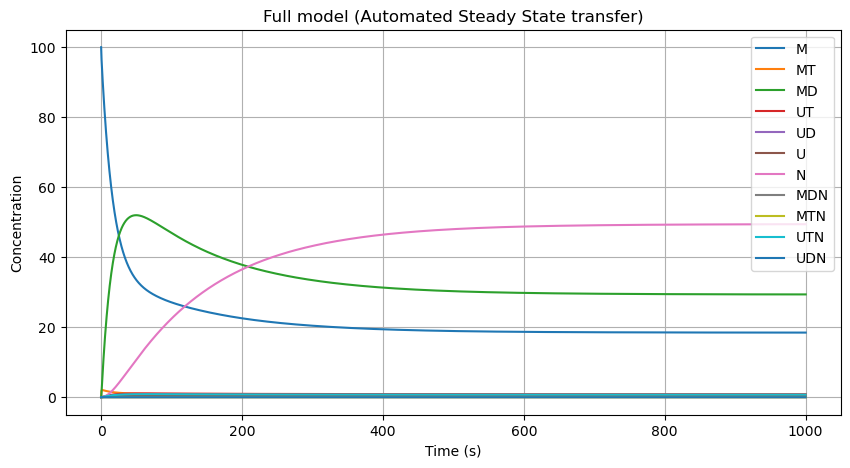

Max N: 49.42845551621656
All k rates:
kMDN_M               : 0.0019492744902636636
kMDN_MD              : 0.033
kMDN_MTN             : 126.84250684418207
kMDN_UDN             : 0.016666666666666666
kMD_M                : 0.0019492744902636636
kMD_MDN              : 0.00020172893863826252
kMD_MT               : 0.018251580833874122
kMD_UD               : 0.016666666666666666
kMTN_M               : 2.3701125844903905
kMTN_MDN             : 0.1592931559628882
kMTN_MT              : 0.1
kMTN_UTN             : 0.016666666666666666
kMT_M                : 2.3701125844903905
kMT_MD               : 1.8000226617740906
kMT_MTN              : 0.0006112998140553411
kMT_UT               : 0.016666666666666666
kM_MD                : 9.965919290982075e-07
kM_MDN               : 5.797182363269897e-10
kM_MT                : 0.09192393620424669
kM_MTN               : 0.0005641426940762564
kM_U                 : 0.0011629949394361457
kN_U                 : 0.005814974697180729
kUDN_MDN             : 0.001

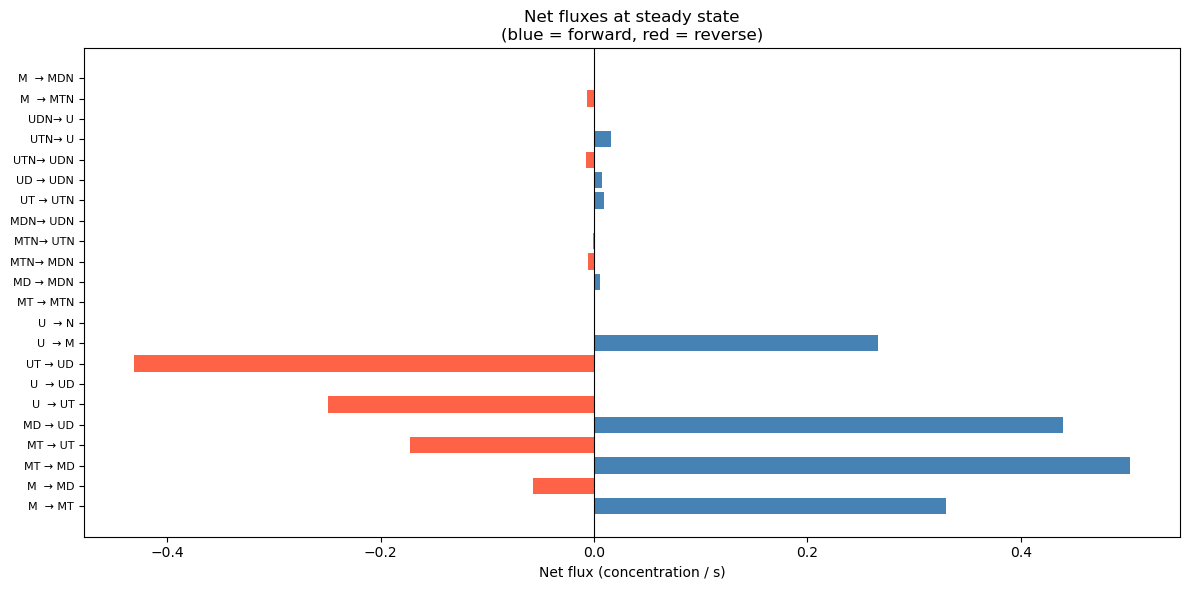

Dominant path: M → MT → MD → UD → UT → U → M


In [32]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def odes_reduced(t, y, k_red, k_NEF_on_T, k_NEF_on_D):
    T, TN, D, DN, NEF = y
    kT_TN = k_NEF_on_T * NEF
    kD_DN = k_NEF_on_D * NEF

    dT  = -(kT_TN + k_red['kT_D']) * T  + k_red['kTN_T']  * TN + k_red['kD_T']  * D
    dTN = -(k_red['kTN_T'] + k_red['kTN_DN']) * TN + kT_TN * T  + k_red['kDN_TN'] * DN
    dD  = -(k_red['kD_T']  + kD_DN)            * D  + k_red['kT_D']  * T  + k_red['kDN_D']  * DN
    dDN = -(k_red['kDN_TN'] + k_red['kDN_D'])  * DN + k_red['kTN_DN'] * TN + kD_DN * D
    dNEF = -(kT_TN * T + kD_DN * D) + (k_red['kTN_T'] * TN + k_red['kDN_D'] * DN)
    return [dT, dTN, dD, dDN, dNEF]


DG_M_M70 = 2.5; DG_M70_U70 = 1.5; DG_U70_U = 0; DG_M_U = 4
tau = 60; beta = 1 / 0.592
kATP_on_base = 1.28e6; kATP_off = 2.31
kADP_on_base = 1000; kADP_off = 2e-3
kATP_plus = 1.3e5; kATP_minus = 1.33e-4
kADP_plus = 2.67e5; kADP_minus = 0.022
ksh = 1.8; k_h = 6e-4
Hsp70 = 10e-6 
NEF0 = 5e-6
ratio_ATP_ADP = 1e-9 
ratio_ATP_ADP_neq = 10

r = kATP_on_base * kADP_off / (kADP_on_base * kATP_off)
kATP_on_base *= r**(-1/4); kATP_off *= r**(1/4)
kADP_on_base *= r**(1/4); kADP_off *= r**(-1/4)

# NEF binding
k_NEF_off_D = 0.033; k_NEF_on_D = 3.4e5
k_NEF_off_T = 0.1; k_NEF_on_T = (k_NEF_on_D / k_NEF_off_D) * k_NEF_off_T
k_NEF_70T_on = 6e6; k_NEF_70T_off = 127; k_NEF_70D_off = 127
k_NEF_70D_on = (k_NEF_70T_on * k_NEF_70D_off / k_NEF_70T_off) * (kATP_minus * kADP_plus) / (kATP_plus * kADP_minus)

# Exchange/Hydrolysis
keff_ex_TD = (kADP_plus * kATP_minus) / (kADP_plus + kATP_plus * ratio_ATP_ADP_neq)
keff_ex_DT = (kADP_minus * kATP_plus * ratio_ATP_ADP_neq) / (kADP_plus + kATP_plus * ratio_ATP_ADP_neq)
k_s = k_h * (kATP_plus * kADP_minus / (kADP_plus * kATP_minus) * ratio_ATP_ADP)
kss = ksh * (k_s / k_h)
kNEF_ex_TD = k_NEF_70T_off * (k_NEF_70D_on / (k_NEF_70T_on * ratio_ATP_ADP_neq + k_NEF_70D_on))
kNEF_ex_DT = k_NEF_70T_on * (k_NEF_70D_off * ratio_ATP_ADP_neq / (k_NEF_70T_on * ratio_ATP_ADP_neq + k_NEF_70D_on))

# Initialisation of reduced model
ratio_Hsp70_ATP_ADP = (keff_ex_DT + k_s) / (keff_ex_TD + k_h)
Hsp70_ADP_0 = Hsp70 / (1 + ratio_Hsp70_ATP_ADP)
Hsp70_ATP_0 = Hsp70 - Hsp70_ADP_0
k_red = {'kT_D': keff_ex_TD + k_h, 'kD_T': keff_ex_DT + k_s, 'kTN_DN': kNEF_ex_TD + k_h, 
         'kDN_TN': kNEF_ex_DT + k_s, 'kTN_T': k_NEF_off_T, 'kDN_D': k_NEF_off_D}

sol_red = solve_ivp(odes_reduced, (0, 10000), [Hsp70_ATP_0, 0.0, Hsp70_ADP_0, 0.0, NEF0],
                    args=(k_red, k_NEF_on_T, k_NEF_on_D), method="BDF", rtol=1e-9, atol=1e-12)

Hsp70_ATP, Hsp70_ATP_NEF, Hsp70_ADP, Hsp70_ADP_NEF, NEF_free = sol_red.y[:, -1]

print(f"Hsp70_ATP: {Hsp70_ATP:.4e}, Hsp70_ADP: {Hsp70_ADP:.4e}, NEF_free: {NEF_free:.4e}\n")





def odes_full(t, y, k):
    M, MT, MD, UT, UD, U, N, MDN, MTN, UTN, UDN = y
    dM = -(k['kM_MT'] + k['kM_MD'] + k['kM_U'] + k['kM_MTN'] + k['kM_MDN']) * M + k['kMT_M'] * MT + k['kMD_M'] * MD + k['kU_M'] * U + k['kMTN_M'] * MTN + k['kMDN_M'] * MDN
    dMT = -(k['kMT_M'] + k['kMT_MD'] + k['kMT_UT'] + k['kMT_MTN']) * MT + k['kM_MT'] * M + k['kMD_MT'] * MD + k['kUT_MT'] * UT + k['kMTN_MT'] * MTN
    dMD = -(k['kMD_M'] + k['kMD_MT'] + k['kMD_UD'] + k['kMD_MDN']) * MD + k['kM_MD'] * M + k['kMT_MD'] * MT + k['kUD_MD'] * UD + k['kMDN_MD'] * MDN
    dUT = -(k['kUT_U'] + k['kUT_UD'] + k['kUT_MT'] + k['kUT_UTN']) * UT + k['kU_UT'] * U + k['kUD_UT'] * UD + k['kMT_UT'] * MT + k['kUTN_UT'] * UTN
    dUD = -(k['kUD_U'] + k['kUD_UT'] + k['kUD_MD'] + k['kUD_UDN']) * UD + k['kU_UD'] * U + k['kUT_UD'] * UT + k['kMD_UD'] * MD + k['kUDN_UD'] * UDN
    dU = -(k['kU_UT'] + k['kU_UD'] + k['kU_M'] + k['kU_N'] + k['kU_UTN'] + k['kU_UDN']) * U + k['kUT_U'] * UT + k['kUD_U'] * UD + k['kM_U'] * M + k['kN_U'] * N + k['kUTN_U'] * UTN + k['kUDN_U'] * UDN
    dN = -k['kN_U'] * N + k['kU_N'] * U
    dMDN = -(k['kMDN_MTN'] + k['kMDN_UDN'] + k['kMDN_MD'] + k['kMDN_M']) * MDN + k['kMTN_MDN'] * MTN + k['kUDN_MDN'] * UDN + k['kMD_MDN'] * MD + k['kM_MDN'] * M
    dMTN = -(k['kMTN_MDN'] + k['kMTN_MT'] + k['kMTN_UTN'] + k['kMTN_M']) * MTN + k['kMDN_MTN'] * MDN + k['kMT_MTN'] * MT + k['kUTN_MTN'] * UTN + k['kM_MTN'] * M
    dUTN = -(k['kUTN_MTN'] + k['kUTN_UT'] + k['kUTN_UDN'] + k['kUTN_U']) * UTN + k['kMTN_UTN'] * MTN + k['kUT_UTN'] * UT + k['kUDN_UTN'] * UDN + k['kU_UTN'] * U
    dUDN = -(k['kUDN_UTN'] + k['kUDN_MDN'] + k['kUDN_UD'] + k['kUDN_U']) * UDN + k['kUTN_UDN'] * UTN + k['kMDN_UDN'] * MDN + k['kUD_UDN'] * UD + k['kU_UDN'] * U
    return [dM, dMT, dMD, dUT, dUD, dU, dN, dMDN, dMTN, dUTN, dUDN]


DG_M70_M70N = 3; DG_M70N_U70N = -1.5; DG_U70_U70N = 0
DG_UTN_U = 0; DG_UDN_U = 0
DG_M_MTN = DG_M_M70 + DG_M70_M70N; DG_M_MDN = DG_M_M70 + DG_M70_M70N
k_TN_on = kATP_on_base; k_TN_off = kATP_off
k_DN_on = kADP_on_base; k_DN_off = kADP_off
alpha = 1; gamma = 5; tau_prime = tau
kATP_MU = kADP_MU = (1/tau) * np.exp(beta * DG_M70_U70)

k = {
    'kM_MT': kATP_on_base * Hsp70_ATP * np.exp(-beta*DG_M_M70),
    'kMT_M': kATP_off,
    'kM_MD': kADP_on_base * Hsp70_ADP * np.exp(-beta*DG_M_M70),
    'kMD_M': kADP_off,
    'kMT_MD': keff_ex_TD + ksh,
    'kMD_MT': keff_ex_DT + kss,
    'kMT_UT': kATP_MU * np.exp(-beta*DG_M70_U70),
    'kUT_MT': kATP_MU,
    'kMD_UD': kADP_MU * np.exp(-beta*DG_M70_U70),
    'kUD_MD': kADP_MU,
    'kUT_U':  kATP_off * np.exp(-beta*DG_U70_U),
    'kU_UT':  kATP_on_base * Hsp70_ATP,
    'kUD_U':  kADP_off * np.exp(-beta*DG_U70_U),
    'kU_UD':  kADP_on_base * Hsp70_ADP,
    'kUT_UD': keff_ex_TD*1e2 + ksh*1e-3,
    'kUD_UT': keff_ex_DT*1e2 + kss*1e-3,
    'kU_M':   alpha,
    'kM_U':   alpha * np.exp(-beta*DG_M_U),
    'kU_N':   alpha,
    'kN_U':   gamma * alpha * np.exp(-beta*DG_M_U),
    'kMTN_MDN': kNEF_ex_TD + ksh * 1e-3,
    'kMDN_MTN': kNEF_ex_DT + kss * 1e-3,
    'kMDN_UDN': 1 / tau_prime,
    'kUDN_MDN': (1 / tau_prime) * np.exp(+beta * DG_M70N_U70N),
    'kMDN_MD':  k_NEF_off_D,
    'kMD_MDN':  k_NEF_on_D * NEF_free * np.exp(-beta * DG_M70_M70N),
    'kMTN_MT':  k_NEF_off_T,
    'kMT_MTN':  k_NEF_on_T * NEF_free * np.exp(-beta * DG_M70_M70N),
    'kMTN_UTN': 1 / tau_prime,
    'kUTN_MTN': (1 / tau_prime) * np.exp(+beta * DG_M70N_U70N),
    'kUT_UTN':  k_NEF_on_T * NEF_free * np.exp(-beta * DG_U70_U70N),
    'kUTN_UT':  k_NEF_off_T,
    'kUTN_UDN': kNEF_ex_TD + ksh * 1e-3,
    'kUDN_UTN': kNEF_ex_DT + kss * 1e-3,
    'kUD_UDN':  k_NEF_on_D * NEF_free * np.exp(-beta * DG_U70_U70N),
    'kUDN_UD':  k_NEF_off_D,
    'kUTN_U':   k_TN_off * np.exp(-beta * DG_UTN_U),
    'kU_UTN':   k_TN_on  * Hsp70_ATP_NEF,
    'kUDN_U':   k_DN_off * np.exp(-beta * DG_UDN_U) ,
    'kU_UDN':   k_DN_on  * Hsp70_ADP_NEF,
    'kMTN_M':   k_TN_off,
    'kM_MTN':   k_TN_on  * Hsp70_ATP_NEF * np.exp(-beta * DG_M_MTN),
    'kMDN_M':   k_DN_off,
    'kM_MDN':   k_DN_on  * Hsp70_ADP_NEF * np.exp(-beta * DG_M_MDN)
}


y0_full = [100, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
sol_full = solve_ivp(odes_full, (0, 1000), y0_full, args=(k,), method="BDF", t_eval=np.linspace(0, 1000, 5000))


plt.figure(figsize=(10, 5))
labels = ["M","MT","MD","UT","UD","U","N","MDN","MTN","UTN","UDN"]
for i, lab in enumerate(labels):
    plt.plot(sol_full.t, sol_full.y[i], label=lab)

plt.xlabel("Time (s)"); plt.ylabel("Concentration"); plt.legend(); plt.grid(True)
plt.title("Full model (Automated Steady State transfer)")
plt.show()

print("Max N:", np.max(sol_full.y[6]))

print("All k rates:")
for key in sorted(k):
    print(f"{key:<20} : {k[key]}")
    
    
    
    

# ---------------- NET FLUXES ----------------
# Net flux J_AB = k_AB * [A]  -  k_BA * [B]

def flux(fwd_rate, A, rev_rate, B):
    return fwd_rate * A - rev_rate * B

M, MT, MD, UT, UD, U, N, MDN, MTN, UTN, UDN = ss

fluxes = {
    
    "M  → MT": flux(k['kM_MT'],   M,   k['kMT_M'],  MT),
    "M  → MD": flux(k['kM_MD'],   M,   k['kMD_M'],  MD),

    "MT → MD": flux(k['kMT_MD'], MT, k['kMD_MT'], MD),

    "MT → UT": flux(k['kMT_UT'], MT, k['kUT_MT'], UT),
    "MD → UD": flux(k['kMD_UD'], MD, k['kUD_MD'], UD),

    "U  → UT": flux(k['kU_UT'],  U,  k['kUT_U'],  UT),
    "U  → UD": flux(k['kU_UD'],  U,  k['kUD_U'],  UD),

    "UT → UD": flux(k['kUT_UD'], UT, k['kUD_UT'], UD),

    "U  → M":  flux(k['kU_M'],   U,  k['kM_U'],   M),
    "U  → N":  flux(k['kU_N'],   U,  k['kN_U'],   N),

    "MT → MTN":flux(k['kMT_MTN'], MT, k['kMTN_MT'], MTN),
    "MD → MDN":flux(k['kMD_MDN'], MD, k['kMDN_MD'], MDN),

    "MTN→ MDN":flux(k['kMTN_MDN'], MTN, k['kMDN_MTN'], MDN),

    "MTN→ UTN":flux(k['kMTN_UTN'], MTN, k['kUTN_MTN'], UTN),
    "MDN→ UDN":flux(k['kMDN_UDN'], MDN, k['kUDN_MDN'], UDN),

    "UT → UTN":flux(k['kUT_UTN'], UT, k['kUTN_UT'], UTN),
    "UD → UDN":flux(k['kUD_UDN'], UD, k['kUDN_UD'], UDN),

    "UTN→ UDN":flux(k['kUTN_UDN'], UTN, k['kUDN_UTN'], UDN),

    "UTN→ U":  flux(k['kUTN_U'], UTN, k['kU_UTN'], U),
    "UDN→ U":  flux(k['kUDN_U'], UDN, k['kU_UDN'], U),

    "M  → MTN":flux(k['kM_MTN'], M,  k['kMTN_M'], MTN),
    "M  → MDN":flux(k['kM_MDN'], M,  k['kMDN_M'], MDN),
}

print("\n\nNet fluxes at steady state")
print(f"{'Transition':<42}  {'Net flux':>14}")
for name, J in fluxes.items():
    direction = "→" if J >= 0 else "←"
    print(f"{name:<42}  {J:+14.4e}   {direction}")

def add_edge(src, dst, J):
    node_flux[src] -= J
    node_flux[dst] += J

add_edge("M",   "MT",  fluxes["M  → MT"])
add_edge("M",   "MD",  fluxes["M  → MD"])
add_edge("MT",  "MD",  fluxes["MT → MD"])
add_edge("MT",  "UT",  fluxes["MT → UT"])
add_edge("MD",  "UD",  fluxes["MD → UD"])
add_edge("U",   "UT",  fluxes["U  → UT"])
add_edge("U",   "UD",  fluxes["U  → UD"])
add_edge("UT",  "UD",  fluxes["UT → UD"])
add_edge("U",   "M",   fluxes["U  → M"])
add_edge("U",   "N",   fluxes["U  → N"])
add_edge("MT",  "MTN", fluxes["MT → MTN"])
add_edge("MD",  "MDN", fluxes["MD → MDN"])
add_edge("MTN", "MDN", fluxes["MTN→ MDN"])
add_edge("MTN", "UTN", fluxes["MTN→ UTN"])
add_edge("MDN", "UDN", fluxes["MDN→ UDN"])
add_edge("UT",  "UTN", fluxes["UT → UTN"])
add_edge("UD",  "UDN", fluxes["UD → UDN"])
add_edge("UTN", "UDN", fluxes["UTN→ UDN"])
add_edge("UTN", "U",   fluxes["UTN→ U"])
add_edge("UDN", "U",   fluxes["UDN→ U"])
add_edge("M",   "MTN", fluxes["M  → MTN"])
add_edge("M",   "MDN", fluxes["M  → MDN"])


# ---------------- BAR CHART OF NET FLUXES---------------- 
fig, ax = plt.subplots(figsize=(12, 6))
names = list(fluxes.keys())
vals  = list(fluxes.values())
colors = ["steelblue" if v >= 0 else "tomato" for v in vals]
ax.barh(names, vals, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Net flux (concentration / s)")
ax.set_title("Net fluxes at steady state\n(blue = forward, red = reverse)")
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

# Dominant path in the model
directed = {}
for name, J in fluxes.items():
    src, dst = [s.strip() for s in name.split("→")]
    if J > 0:
        directed.setdefault(src, []).append((dst,  J))
    else:
        directed.setdefault(dst, []).append((src, -J))

node, path = "M", ["M"]
for _ in range(20):
    neighbors = directed.get(node, [])
    if not neighbors: break
    node, J = max(neighbors, key=lambda x: x[1])
    if node in path: path.append(node); break
    path.append(node)

print("Dominant path:", " → ".join(path))

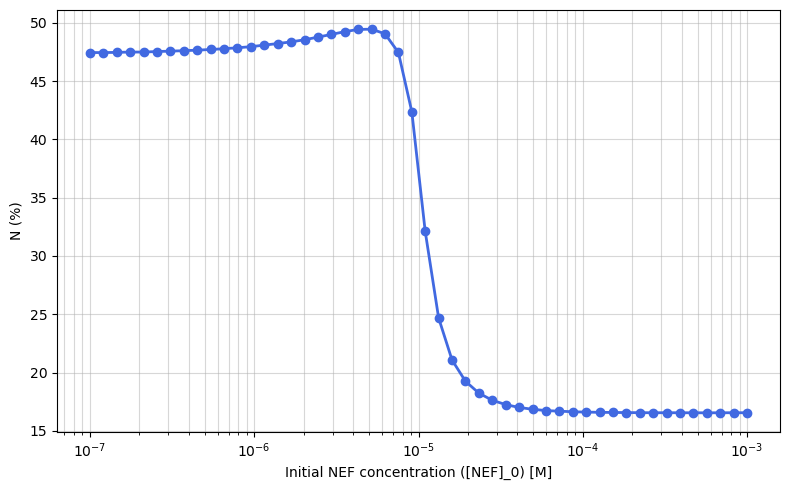

In [8]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


def odes_reduced(t, y, k_red, k_NEF_on_T, k_NEF_on_D):
    T, TN, D, DN, NEF = y
    kT_TN = k_NEF_on_T * NEF
    kD_DN = k_NEF_on_D * NEF
    dT  = -(kT_TN + k_red['kT_D']) * T  + k_red['kTN_T']  * TN + k_red['kD_T']  * D
    dTN = -(k_red['kTN_T'] + k_red['kTN_DN']) * TN + kT_TN * T  + k_red['kDN_TN'] * DN
    dD  = -(k_red['kD_T']  + kD_DN)            * D  + k_red['kT_D']  * T  + k_red['kDN_D']  * DN
    dDN = -(k_red['kDN_TN'] + k_red['kDN_D'])  * DN + k_red['kTN_DN'] * TN + kD_DN * D
    dNEF = -(kT_TN * T + kD_DN * D) + (k_red['kTN_T'] * TN + k_red['kDN_D'] * DN)
    return [dT, dTN, dD, dDN, dNEF]

def odes_full(t, y, k):
    M, MT, MD, UT, UD, U, N, MDN, MTN, UTN, UDN = y
    
    dM = -(k['kM_MT'] + k['kM_MD'] + k['kM_U'] + k['kM_MTN'] + k['kM_MDN']) * M + k['kMT_M'] * MT + k['kMD_M'] * MD + k['kU_M'] * U + k['kMTN_M'] * MTN + k['kMDN_M'] * MDN
    dMT = -(k['kMT_M'] + k['kMT_MD'] + k['kMT_UT'] + k['kMT_MTN']) * MT + k['kM_MT'] * M + k['kMD_MT'] * MD + k['kUT_MT'] * UT + k['kMTN_MT'] * MTN
    dMD = -(k['kMD_M'] + k['kMD_MT'] + k['kMD_UD'] + k['kMD_MDN']) * MD + k['kM_MD'] * M + k['kMT_MD'] * MT + k['kUD_MD'] * UD + k['kMDN_MD'] * MDN
    dUT = -(k['kUT_U'] + k['kUT_UD'] + k['kUT_MT'] + k['kUT_UTN']) * UT + k['kU_UT'] * U + k['kUD_UT'] * UD + k['kMT_UT'] * MT + k['kUTN_UT'] * UTN
    dUD = -(k['kUD_U'] + k['kUD_UT'] + k['kUD_MD'] + k['kUD_UDN']) * UD + k['kU_UD'] * U + k['kUT_UD'] * UT + k['kMD_UD'] * MD + k['kUDN_UD'] * UDN
    dU = -(k['kU_UT'] + k['kU_UD'] + k['kU_M'] + k['kU_N'] + k['kU_UTN'] + k['kU_UDN']) * U + k['kUT_U'] * UT + k['kUD_U'] * UD + k['kM_U'] * M + k['kN_U'] * N + k['kUTN_U'] * UTN + k['kUDN_U'] * UDN
    dN = -k['kN_U'] * N + k['kU_N'] * U
    dMDN = -(k['kMDN_MTN'] + k['kMDN_UDN'] + k['kMDN_MD'] + k['kMDN_M']) * MDN + k['kMTN_MDN'] * MTN + k['kUDN_MDN'] * UDN + k['kMD_MDN'] * MD + k['kM_MDN'] * M
    dMTN = -(k['kMTN_MDN'] + k['kMTN_MT'] + k['kMTN_UTN'] + k['kMTN_M']) * MTN + k['kMDN_MTN'] * MDN + k['kMT_MTN'] * MT + k['kUTN_MTN'] * UTN + k['kM_MTN'] * M
    dUTN = -(k['kUTN_MTN'] + k['kUTN_UT'] + k['kUTN_UDN'] + k['kUTN_U']) * UTN + k['kMTN_UTN'] * MTN + k['kUT_UTN'] * UT + k['kUDN_UTN'] * UDN + k['kU_UTN'] * U
    dUDN = -(k['kUDN_UTN'] + k['kUDN_MDN'] + k['kUDN_UD'] + k['kUDN_U']) * UDN + k['kUTN_UDN'] * UTN + k['kMDN_UDN'] * MDN + k['kUD_UDN'] * UD + k['kU_UDN'] * U
    return [dM, dMT, dMD, dUT, dUD, dU, dN, dMDN, dMTN, dUTN, dUDN]


beta = 1 / 0.592
kATP_on_base, kATP_off = 1.28e6, 2.31
kADP_on_base, kADP_off = 1000, 2e-3
kATP_plus, kATP_minus = 1.3e5, 1.33e-4
kADP_plus, kADP_minus = 2.67e5, 0.022
ksh, k_h = 1.8, 6e-4
Hsp70, ratio_ATP_ADP_neq, ratio_ATP_ADP = 10e-6, 10, 1e-9


r = kATP_on_base * kADP_off / (kADP_on_base * kATP_off)
kATP_on_base *= r**(-1/4); kATP_off *= r**(1/4)
kADP_on_base *= r**(1/4); kADP_off *= r**(-1/4)

k_NEF_off_D, k_NEF_on_D = 0.033, 3.4e5
k_NEF_off_T = 0.1; k_NEF_on_T = (k_NEF_on_D / k_NEF_off_D) * k_NEF_off_T
keff_ex_TD = (kADP_plus * kATP_minus) / (kADP_plus + kATP_plus * ratio_ATP_ADP_neq)
keff_ex_DT = (kADP_minus * kATP_plus * ratio_ATP_ADP_neq) / (kADP_plus + kATP_plus * ratio_ATP_ADP_neq)
k_s = k_h * (kATP_plus * kADP_minus / (kADP_plus * kATP_minus) * ratio_ATP_ADP)
kss = ksh * (k_s / k_h)

kNEF_70T_on, kNEF_70T_off, kNEF_70D_off = 6e6, 127, 127
kNEF_70D_on = (kNEF_70T_on * kNEF_70D_off / kNEF_70T_off) * (kATP_minus * kADP_plus) / (kATP_plus * kADP_minus)
kNEF_ex_TD = kNEF_70T_off * (kNEF_70D_on / (kNEF_70T_on * ratio_ATP_ADP_neq + kNEF_70D_on))
kNEF_ex_DT = kNEF_70T_on * (kNEF_70D_off * ratio_ATP_ADP_neq / (kNEF_70T_on * ratio_ATP_ADP_neq + kNEF_70D_on))

k_red_base = {'kT_D': keff_ex_TD + k_h, 'kD_T': keff_ex_DT + k_s, 'kTN_DN': kNEF_ex_TD + k_h, 
              'kDN_TN': kNEF_ex_DT + k_s, 'kTN_T': k_NEF_off_T, 'kDN_D': k_NEF_off_D}

#Scan
nef_values = np.logspace(-7, -3, 50)
max_n_results = []


for nef0_val in nef_values:
    
    ratio_Hsp70_ATP_ADP = (keff_ex_DT + k_s) / (keff_ex_TD + k_h)
    H_ADP_0 = Hsp70 / (1 + ratio_Hsp70_ATP_ADP)
    H_ATP_0 = Hsp70 - H_ADP_0
    
    sol_r = solve_ivp(odes_reduced, (0, 10000), [H_ATP_0, 0.0, H_ADP_0, 0.0, nef0_val],
                      args=(k_red_base, k_NEF_on_T, k_NEF_on_D), method="BDF")
    
    
    H_ATP_ss, H_ATP_N_ss, H_ADP_ss, H_ADP_N_ss, N_free_ss = sol_r.y[:, -1]

    
    DG_M_M70, DG_M70_U70, DG_M_U = 2.5, 1.5, 4
    DG_M70_M70N, DG_M70N_U70N, DG_U70_U70N = 3, -1.5, 0
    alpha, gamma, tau_prime = 1, 5, 60
    kATP_MU = (1/60) * np.exp(beta * DG_M70_U70)
    
    k_full = {
        'kM_MT': kATP_on_base * H_ATP_ss * np.exp(-beta*2.5), 'kMT_M': kATP_off,
        'kM_MD': kADP_on_base * H_ADP_ss * np.exp(-beta*2.5), 'kMD_M': kADP_off,
        'kMT_MD': keff_ex_TD + ksh, 'kMD_MT': keff_ex_DT + kss,
        'kMT_UT': kATP_MU * np.exp(-beta*1.5), 'kUT_MT': kATP_MU,
        'kMD_UD': kATP_MU * np.exp(-beta*1.5), 'kUD_MD': kATP_MU,
        'kUT_U':  kATP_off, 'kU_UT':  kATP_on_base * H_ATP_ss,
        'kUD_U':  kADP_off, 'kU_UD':  kADP_on_base * H_ADP_ss,
        'kUT_UD': keff_ex_TD*100, 'kUD_UT': keff_ex_DT*100,
        'kU_M': alpha, 'kM_U': alpha * np.exp(-beta*4), 'kU_N': alpha, 'kN_U': gamma * alpha * np.exp(-beta*4),
        'kMTN_MDN': kNEF_ex_TD, 'kMDN_MTN': kNEF_ex_DT, 'kMDN_UDN': 1/60, 'kUDN_MDN': (1/60)*np.exp(beta*-1.5),
        'kMDN_MD': k_NEF_off_D, 'kMD_MDN': k_NEF_on_D * N_free_ss * np.exp(-beta*3),
        'kMTN_MT': k_NEF_off_T, 'kMT_MTN': k_NEF_on_T * N_free_ss * np.exp(-beta*3),
        'kMTN_UTN': 1/60, 'kUTN_MTN': (1/60)*np.exp(beta*-1.5),
        'kUT_UTN': k_NEF_on_T * N_free_ss, 'kUTN_UT': k_NEF_off_T,
        'kUTN_UDN': kNEF_ex_TD, 'kUDN_UTN': kNEF_ex_DT,
        'kUD_UDN': k_NEF_on_D * N_free_ss, 'kUDN_UD': k_NEF_off_D,
        'kUTN_U': kATP_off, 'kU_UTN': kATP_on_base * H_ATP_N_ss,
        'kUDN_U': kADP_off, 'kU_UDN': kADP_on_base * H_ADP_N_ss,
        'kMTN_M': kATP_off, 'kM_MTN': kATP_on_base * H_ATP_N_ss * np.exp(-beta*5.5),
        'kMDN_M': kADP_off, 'kM_MDN': kADP_on_base * H_ADP_N_ss * np.exp(-beta*5.5)
    }

    
    sol_f = solve_ivp(odes_full, (0, 2000), [100, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 
                      args=(k_full,), method="BDF")
    
    max_n_results.append(np.max(sol_f.y[6]))

plt.figure(figsize=(8, 5))
plt.semilogx(nef_values, max_n_results, 'o-', color='royalblue', lw=2)
plt.xlabel("Initial NEF concentration ([NEF]_0) [M]")
plt.ylabel("N (%)")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.tight_layout()
plt.show()

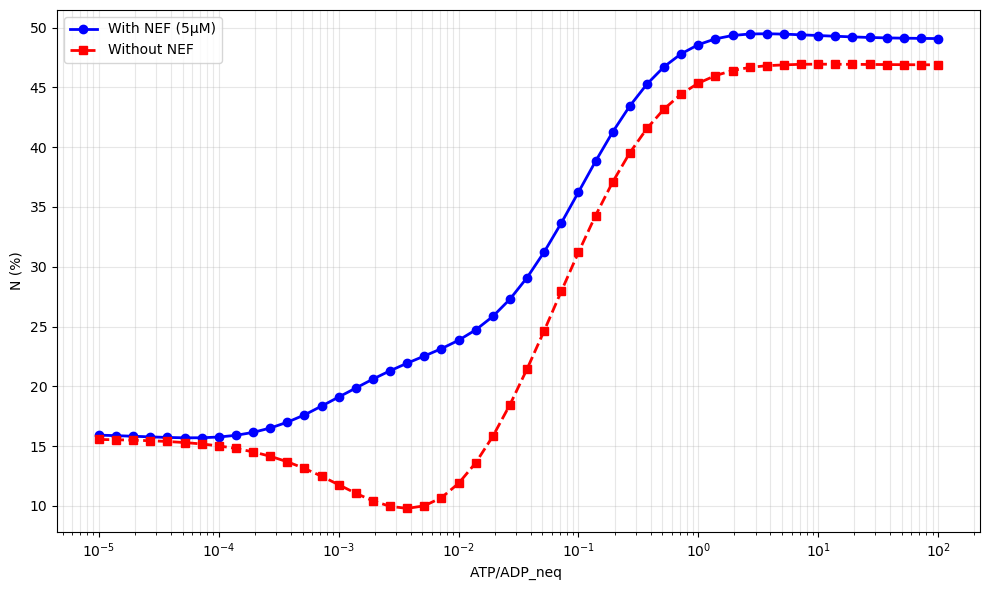

In [9]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


def odes_reduced(t, y, k_red, k_on_T, k_on_D):
    T, TN, D, DN, NEF = y
    kT_TN, kD_DN = k_on_T * NEF, k_on_D * NEF
    return [
        -(kT_TN + k_red['kT_D']) * T  + k_red['kTN_T'] * TN + k_red['kD_T'] * D,
        -(k_red['kTN_T'] + k_red['kTN_DN']) * TN + kT_TN * T + k_red['kDN_TN'] * DN,
        -(k_red['kD_T'] + kD_DN) * D + k_red['kT_D'] * T + k_red['kDN_D'] * DN,
        -(k_red['kDN_TN'] + k_red['kDN_D']) * DN + k_red['kTN_DN'] * TN + kD_DN * D,
        -(kT_TN * T + kD_DN * D) + (k_red['kTN_T'] * TN + k_red['kDN_D'] * DN)
    ]

def odes_full(t, y, k):
    M, MT, MD, UT, UD, U, N, MDN, MTN, UTN, UDN = y
    dM = -(k['kM_MT'] + k['kM_MD'] + k['kM_U'] + k['kM_MTN'] + k['kM_MDN']) * M + k['kMT_M'] * MT + k['kMD_M'] * MD + k['kU_M'] * U + k['kMTN_M'] * MTN + k['kMDN_M'] * MDN
    dMT = -(k['kMT_M'] + k['kMT_MD'] + k['kMT_UT'] + k['kMT_MTN']) * MT + k['kM_MT'] * M + k['kMD_MT'] * MD + k['kUT_MT'] * UT + k['kMTN_MT'] * MTN
    dMD = -(k['kMD_M'] + k['kMD_MT'] + k['kMD_UD'] + k['kMD_MDN']) * MD + k['kM_MD'] * M + k['kMT_MD'] * MT + k['kUD_MD'] * UD + k['kMDN_MD'] * MDN
    dUT = -(k['kUT_U'] + k['kUT_UD'] + k['kUT_MT'] + k['kUT_UTN']) * UT + k['kU_UT'] * U + k['kUD_UT'] * UD + k['kMT_UT'] * MT + k['kUTN_UT'] * UTN
    dUD = -(k['kUD_U'] + k['kUD_UT'] + k['kUD_MD'] + k['kUD_UDN']) * UD + k['kU_UD'] * U + k['kUT_UD'] * UT + k['kMD_UD'] * MD + k['kUDN_UD'] * UDN
    dU = -(k['kU_UT'] + k['kU_UD'] + k['kU_M'] + k['kU_N'] + k['kU_UTN'] + k['kU_UDN']) * U + k['kUT_U'] * UT + k['kUD_U'] * UD + k['kM_U'] * M + k['kN_U'] * N + k['kUTN_U'] * UTN + k['kUDN_U'] * UDN
    dN = -k['kN_U'] * N + k['kU_N'] * U
    dMDN = -(k['kMDN_MTN'] + k['kMDN_UDN'] + k['kMDN_MD'] + k['kMDN_M']) * MDN + k['kMTN_MDN'] * MTN + k['kUDN_MDN'] * UDN + k['kMD_MDN'] * MD + k['kM_MDN'] * M
    dMTN = -(k['kMTN_MDN'] + k['kMTN_MT'] + k['kMTN_UTN'] + k['kMTN_M']) * MTN + k['kMDN_MTN'] * MDN + k['kMT_MTN'] * MT + k['kUTN_MTN'] * UTN + k['kM_MTN'] * M
    dUTN = -(k['kUTN_MTN'] + k['kUTN_UT'] + k['kUTN_UDN'] + k['kUTN_U']) * UTN + k['kMTN_UTN'] * MTN + k['kUT_UTN'] * UT + k['kUDN_UTN'] * UDN + k['kU_UTN'] * U
    dUDN = -(k['kUDN_UTN'] + k['kUDN_MDN'] + k['kUDN_UD'] + k['kUDN_U']) * UDN + k['kUTN_UDN'] * UTN + k['kMDN_UDN'] * MDN + k['kUD_UDN'] * UD + k['kU_UDN'] * U
    return [dM, dMT, dMD, dUT, dUD, dU, dN, dMDN, dMTN, dUTN, dUDN]


beta = 1 / 0.592
kATP_on_base, kATP_off = 1.28e6, 2.31
kADP_on_base, kADP_off = 1000, 2e-3
kATP_plus, kATP_minus = 1.3e5, 1.33e-4
kADP_plus, kADP_minus = 2.67e5, 0.022
ksh, k_h = 1.8, 6e-4
Hsp70, ratio_ATP_ADP_eq = 10e-6, 1e-9


ratios_neq = np.logspace(-5, 2, 50)  
results_with_nef = []
results_without_nef = []

def run_simulation(ratio_val, nef0_val):
    
    keff_ex_TD = (kADP_plus * kATP_minus) / (kADP_plus + kATP_plus * ratio_val)
    keff_ex_DT = (kADP_minus * kATP_plus * ratio_val) / (kADP_plus + kATP_plus * ratio_val)
    k_s_val = k_h * (kATP_plus * kADP_minus / (kADP_plus * kATP_minus) * ratio_ATP_ADP_eq)
    kss_val = ksh * (k_s_val / k_h)
    
    kNEF_70T_on, kNEF_70T_off, kNEF_70D_off = 6e6, 127, 127
    kNEF_70D_on = (kNEF_70T_on * kNEF_70D_off / kNEF_70T_off) * (kATP_minus * kADP_plus) / (kATP_plus * kADP_minus)
    kNEF_ex_TD = kNEF_70T_off * (kNEF_70D_on / (kNEF_70T_on * ratio_val + kNEF_70D_on))
    kNEF_ex_DT = kNEF_70T_on * (kNEF_70D_off * ratio_val / (kNEF_70T_on * ratio_val + kNEF_70D_on))

    k_red = {'kT_D': keff_ex_TD + k_h, 'kD_T': keff_ex_DT + k_s_val, 'kTN_DN': kNEF_ex_TD + k_h, 
             'kDN_TN': kNEF_ex_DT + k_s_val, 'kTN_T': 0.1, 'kDN_D': 0.033}
    
    H_ADP_0 = Hsp70 / (1 + (keff_ex_DT + k_s_val) / (keff_ex_TD + k_h))
    H_ATP_0 = Hsp70 - H_ADP_0
    
    sol_r = solve_ivp(odes_reduced, (0, 10000), [H_ATP_0, 0, H_ADP_0, 0, nef0_val], 
                      args=(k_red, 1.03e6, 3.4e5), method="BDF")
    H_ATP_ss, H_ATP_N_ss, H_ADP_ss, H_ADP_N_ss, N_free_ss = sol_r.y[:, -1]

    alpha = 1
    k_full = {
        'kM_MT': kATP_on_base * H_ATP_ss * np.exp(-beta*2.5), 'kMT_M': kATP_off,
        'kM_MD': kADP_on_base * H_ADP_ss * np.exp(-beta*2.5), 'kMD_M': kADP_off,
        'kMT_MD': keff_ex_TD + ksh, 'kMD_MT': keff_ex_DT + kss_val,
        'kMT_UT': 1/60, 'kUT_MT': (1/60)*np.exp(beta*1.5), 'kMD_UD': 1/60, 'kUD_MD': (1/60)*np.exp(beta*1.5),
        'kUT_U': kATP_off, 'kU_UT': kATP_on_base * H_ATP_ss, 'kUD_U': kADP_off, 'kU_UD': kADP_on_base * H_ADP_ss,
        'kUT_UD': keff_ex_TD*100, 'kUD_UT': keff_ex_DT*100,
        'kU_M': alpha, 'kM_U': alpha*np.exp(-beta*4), 'kU_N': alpha, 'kN_U': 5*alpha*np.exp(-beta*4),
        'kMTN_MDN': kNEF_ex_TD, 'kMDN_MTN': kNEF_ex_DT, 'kMDN_UDN': 1/60, 'kUDN_MDN': (1/60)*np.exp(beta*-1.5),
        'kMDN_MD': 0.033, 'kMD_MDN': 3.4e5 * N_free_ss * np.exp(-beta*3),
        'kMTN_MT': 0.1, 'kMT_MTN': 1.03e6 * N_free_ss * np.exp(-beta*3),
        'kMTN_UTN': 1/60, 'kUTN_MTN': (1/60)*np.exp(beta*-1.5),
        'kUT_UTN': 1.03e6 * N_free_ss, 'kUTN_UT': 0.1, 'kUTN_UDN': kNEF_ex_TD, 'kUDN_UTN': kNEF_ex_DT,
        'kUD_UDN': 3.4e5 * N_free_ss, 'kUDN_UD': 0.033,
        'kUTN_U': kATP_off, 'kU_UTN': kATP_on_base * H_ATP_N_ss, 'kUDN_U': kADP_off, 'kU_UDN': kADP_on_base * H_ADP_N_ss,
        'kMTN_M': kATP_off, 'kM_MTN': kATP_on_base * H_ATP_N_ss * np.exp(-beta*5.5),
        'kMDN_M': kADP_off, 'kM_MDN': kADP_on_base * H_ADP_N_ss * np.exp(-beta*5.5)
    }
    
    sol_f = solve_ivp(odes_full, (0, 5000), [100, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], args=(k_full,), method="BDF")
    return sol_f.y[6, -1] 

for r_val in ratios_neq:
    results_with_nef.append(run_simulation(r_val, 5e-6))
    results_without_nef.append(run_simulation(r_val, 0.0))

plt.figure(figsize=(10, 6))
plt.plot(ratios_neq, results_with_nef, 'o-', label="With NEF (5µM)", color='blue', lw=2)
plt.plot(ratios_neq, results_without_nef, 's--', label="Without NEF", color='red', lw=2)

plt.xscale("log")
plt.xlabel("ATP/ADP_neq ")
plt.ylabel("N (%)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.tight_layout()
plt.show()